### Modelo para detección de outliers y cambio de patrón con AR

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
import changefinder

In [2]:
df = pd.read_csv('../df_procesados/df_planta_2.csv')
df['date_time'] = pd.to_datetime(df['date_time'])

#### Función que detecta outliers y cambios según paper: "A Unifying Framework for Detecting Outliers and Change Points from Time Series"

In [3]:
def AR_outlier(
    df,
    col: str,
    lag_ar: int = 2, # AR(2)
    alpha: float = 0.01, 
    quantile: float = 0.9995,

    factor_olvido: float = 0.01,   # factor de olvido (más pequeño = olvida más rápido)
    lag_cambio: int = 1,           # AR cambio 
    suavizado: int = 5,         
    change_quantile: float = 0.999
):
    df = df.copy()

    df["date_time"] = pd.to_datetime(df["date_time"])
    df = df.sort_values("date_time").reset_index(drop=True)

    df = df.dropna(subset=[col])

    x = df[col].astype(float).values
    n = len(x)

    ar = AutoReg(x, lags=lag_ar, old_names=False)
    mod = ar.fit()

    pred = mod.predict(start=lag_ar, end=n-1, dynamic=False)  # ndarray
    residuos = np.full(n, np.nan, dtype=float)
    residuos[lag_ar:] = x[lag_ar:] - pred

    serie_residuos = pd.Series(residuos)
    var_inicial = np.nanvar(serie_residuos.values)
    if not np.isfinite(var_inicial) or var_inicial <= 0:
        var_inicial = 1.0

    s2 = []
    s2_curr = var_inicial
    for r in serie_residuos.values:
        if np.isfinite(r):
            s2_curr = (1 - alpha) * s2_curr + alpha * (r**2)
        s2.append(max(s2_curr, 1e-8))
    s2 = np.array(s2, dtype=float)

    outlier_score = 0.5 * (np.log(2 * np.pi * s2) + (residuos**2) / s2)

    valid_out = np.isfinite(outlier_score)
    thr_out = np.quantile(outlier_score[valid_out], quantile) if valid_out.any() else np.inf
    is_out = outlier_score >= thr_out


    cf = changefinder.ChangeFinder(r=factor_olvido, order=lag_cambio, smooth=suavizado)
    score_cambio = np.array([cf.update(float(v)) for v in x], dtype=float)

    valid_ch = np.isfinite(score_cambio)
    thr_ch = np.quantile(score_cambio[valid_ch], change_quantile) if valid_ch.any() else np.inf
    is_ch = score_cambio >= thr_ch


    labels = np.full(n, "normal", dtype=object)
    labels[is_out] = "outlier"
    labels[is_ch]  = "change"   

    df["outlier_score"] = outlier_score
    df["change_score"] = score_cambio
    df["label"] = labels

    return df

In [4]:
df.columns

Index(['date_time', 'Flujo Cámara de contacto 1',
       'Flujo Salida de Lodo Sedimentador Secundario 3',
       'Flujo Aire Reactor 2', 'Nivel Pozo WAS', 'OD Reactor 2',
       'Flujo Afluente PTAR', 'Flujo Alimentación Digestor 1',
       'Flujo Alimentación Digestor 2', 'Flujo Alimentación Digestor 3',
       'Flujo Aire Reactor 1', 'Flujo Aire Reactor 3', 'OD Reactor 1',
       'Flujo Cámara de contacto 2'],
      dtype='object')

In [5]:
col = df.columns[9]
col

'Flujo Alimentación Digestor 3'

In [6]:
df_test = df[["date_time", col]]

if "pH" in col:
    df_test = df_test[df_test[col] <= 14]

In [7]:
df_etiquetado = AR_outlier(df_test, col)

##### Veamos graficamente los outliers y cambios detectados

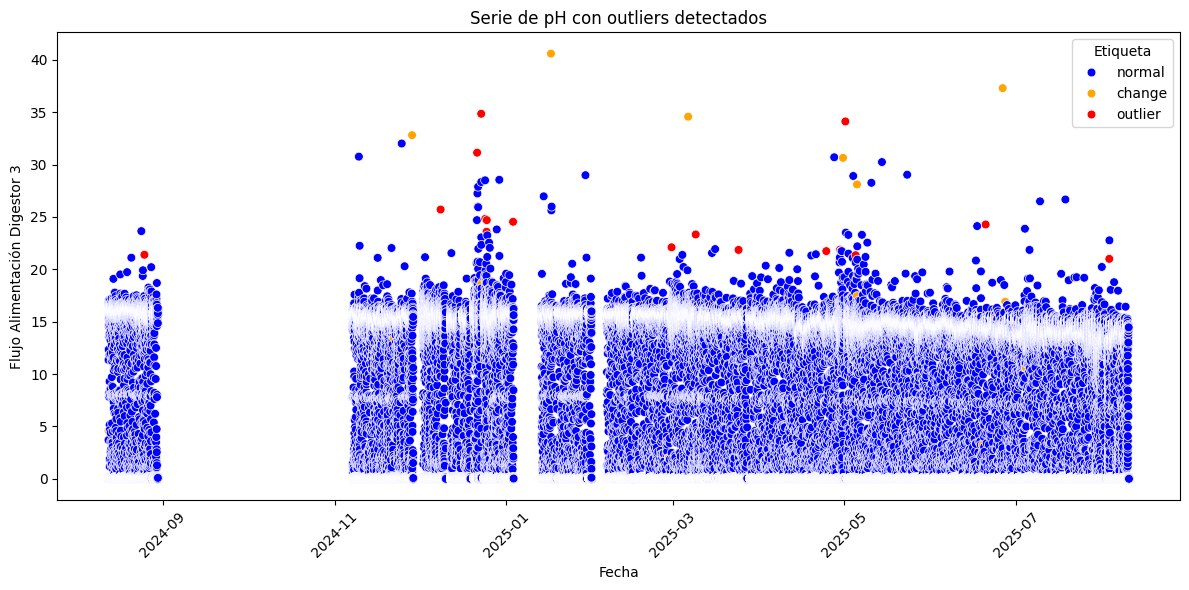

In [8]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df_etiquetado,
    x="date_time",
    y= col,
    hue="label",
    palette={"normal":"blue", "outlier":"red", "change":"orange"},
    s=40
)
plt.title("Serie de pH con outliers detectados")
plt.xlabel("Fecha")
plt.ylabel(f"{col}")
plt.legend(title="Etiqueta")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
df_etiquetado.describe()

,date_time,pH coagulación entrada DAF,outlier_score,change_score
count,82006,82006.000000,82004.000000,82006.000000
mean,2025-06-30 04:47:10.879691776,6.691828,-2.287697,4.823272
min,2025-05-22 20:46:00,0.139757,-5.475852,-0.136750
25%,2025-06-06 20:23:15,6.091074,-3.290401,3.772781
50%,2025-07-06 00:48:30,6.936198,-2.732756,4.491453
75%,2025-07-20 19:29:45,7.227358,-1.513315,5.060802
max,2025-08-09 23:58:00,14.000000,50.615200,89.654742
std,NaN,1.026919,2.028119,2.997522


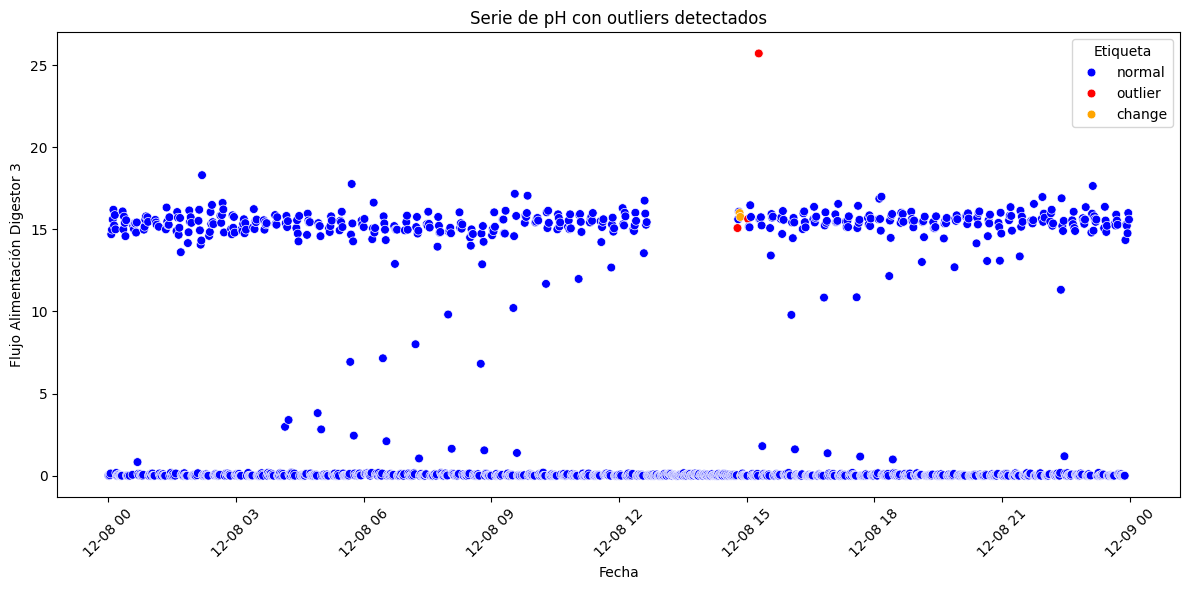

In [11]:
num_outlier = 8

outliers = df_etiquetado.index[df_etiquetado["label"] == "outlier"]

id_outlier = outliers[num_outlier]
data_outlier = df_etiquetado.loc[id_outlier, "date_time"]

dia_mask = df_etiquetado["date_time"].dt.date == data_outlier.date()
df_dia = df_etiquetado[dia_mask]

plt.figure(figsize=(12,6))
sns.scatterplot(
    data=df_dia,
    x="date_time",
    y= col,
    hue="label",
    palette={"normal":"blue", "outlier":"red", "change":"orange"},
    s=40
)
plt.title("Serie de pH con outliers detectados")
plt.xlabel("Fecha")
plt.ylabel(f"{col}")
plt.legend(title="Etiqueta")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()